In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Setup and Data Paths

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
from scipy.stats import norm
from joblib import Parallel, delayed
from sklearn.metrics import precision_recall_curve, roc_curve, auc as sklearn_auc
from statsmodels.regression.quantile_regression import QuantReg
from rasterio.features import rasterize
from shapely.geometry import box

beirut_path      = '/content/drive/MyDrive/Beirut'
coherence_folder = os.path.join(beirut_path, 'Coherence_Maps_Beirut')
ground_truth_folder = os.path.join(beirut_path, '2020_ZKI_Beirut_explosion_damage_detection')

## Load Coherence Maps

In [3]:
coherence_files = sorted(glob.glob(os.path.join(coherence_folder, '*.tif')))

coherence_stack = []
dates = []

for file in coherence_files:
    parts = os.path.basename(file).split('_')
    dates.append(f"{parts[1]}_{parts[2]}")
    with rasterio.open(file) as src:
        coherence_stack.append(src.read(1))

# First coherence map properties
with rasterio.open(coherence_files[0]) as src:
    raster_transform = src.transform
    raster_crs       = src.crs
    raster_shape     = (src.height, src.width)

EXPLOSION_IDX      = 9   # period containing Aug 4, 2020
EXPLOSION_DIFF_IDX = EXPLOSION_IDX - 1  # index into diff/residual matrices

print(f"Loaded {len(coherence_stack)} coherence maps")
print(f"Raster shape: {raster_shape}")
for i, d in enumerate(dates):
    print(f"  {i:2d}. {d}{'  <- explosion' if i == EXPLOSION_IDX else ''}")

Loaded 22 coherence maps
Raster shape: (685, 945)
   0. 20200406_20200418
   1. 20200418_20200430
   2. 20200430_20200512
   3. 20200512_20200524
   4. 20200524_20200605
   5. 20200605_20200617
   6. 20200617_20200629
   7. 20200629_20200711
   8. 20200711_20200723
   9. 20200723_20200804  <- explosion
  10. 20200804_20200816
  11. 20200816_20200828
  12. 20200828_20200909
  13. 20200909_20200921
  14. 20200921_20201003
  15. 20201003_20201015
  16. 20201015_20201027
  17. 20201027_20201108
  18. 20201108_20201120
  19. 20201120_20201202
  20. 20201202_20201214
  21. 20201214_20201226


## Visualise Coherence Maps

/tmp/ipykernel_3162/3975548575.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


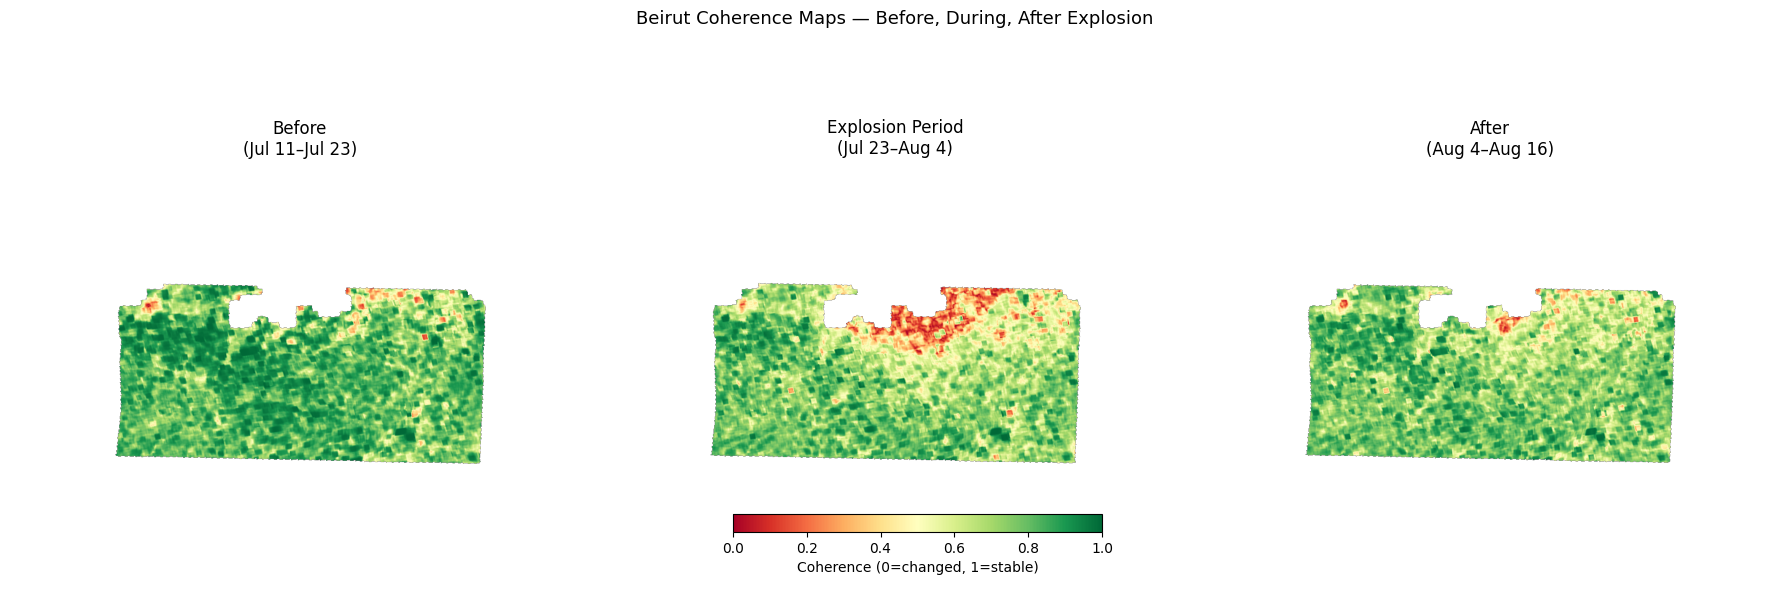

In [4]:
# Before, during, after explosion
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Before\n(Jul 11–Jul 23)', 'Explosion Period\n(Jul 23–Aug 4)', 'After\n(Aug 4–Aug 16)']
for ax, idx, title in zip(axes, [8, 9, 10], titles):
    im = ax.imshow(coherence_stack[idx], cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12)
    ax.axis('off')
fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.04,
             pad=0.06, label='Coherence (0=changed, 1=stable)')
plt.suptitle('Beirut Coherence Maps — Before, During, After Explosion', fontsize=13)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3162/3067649892.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


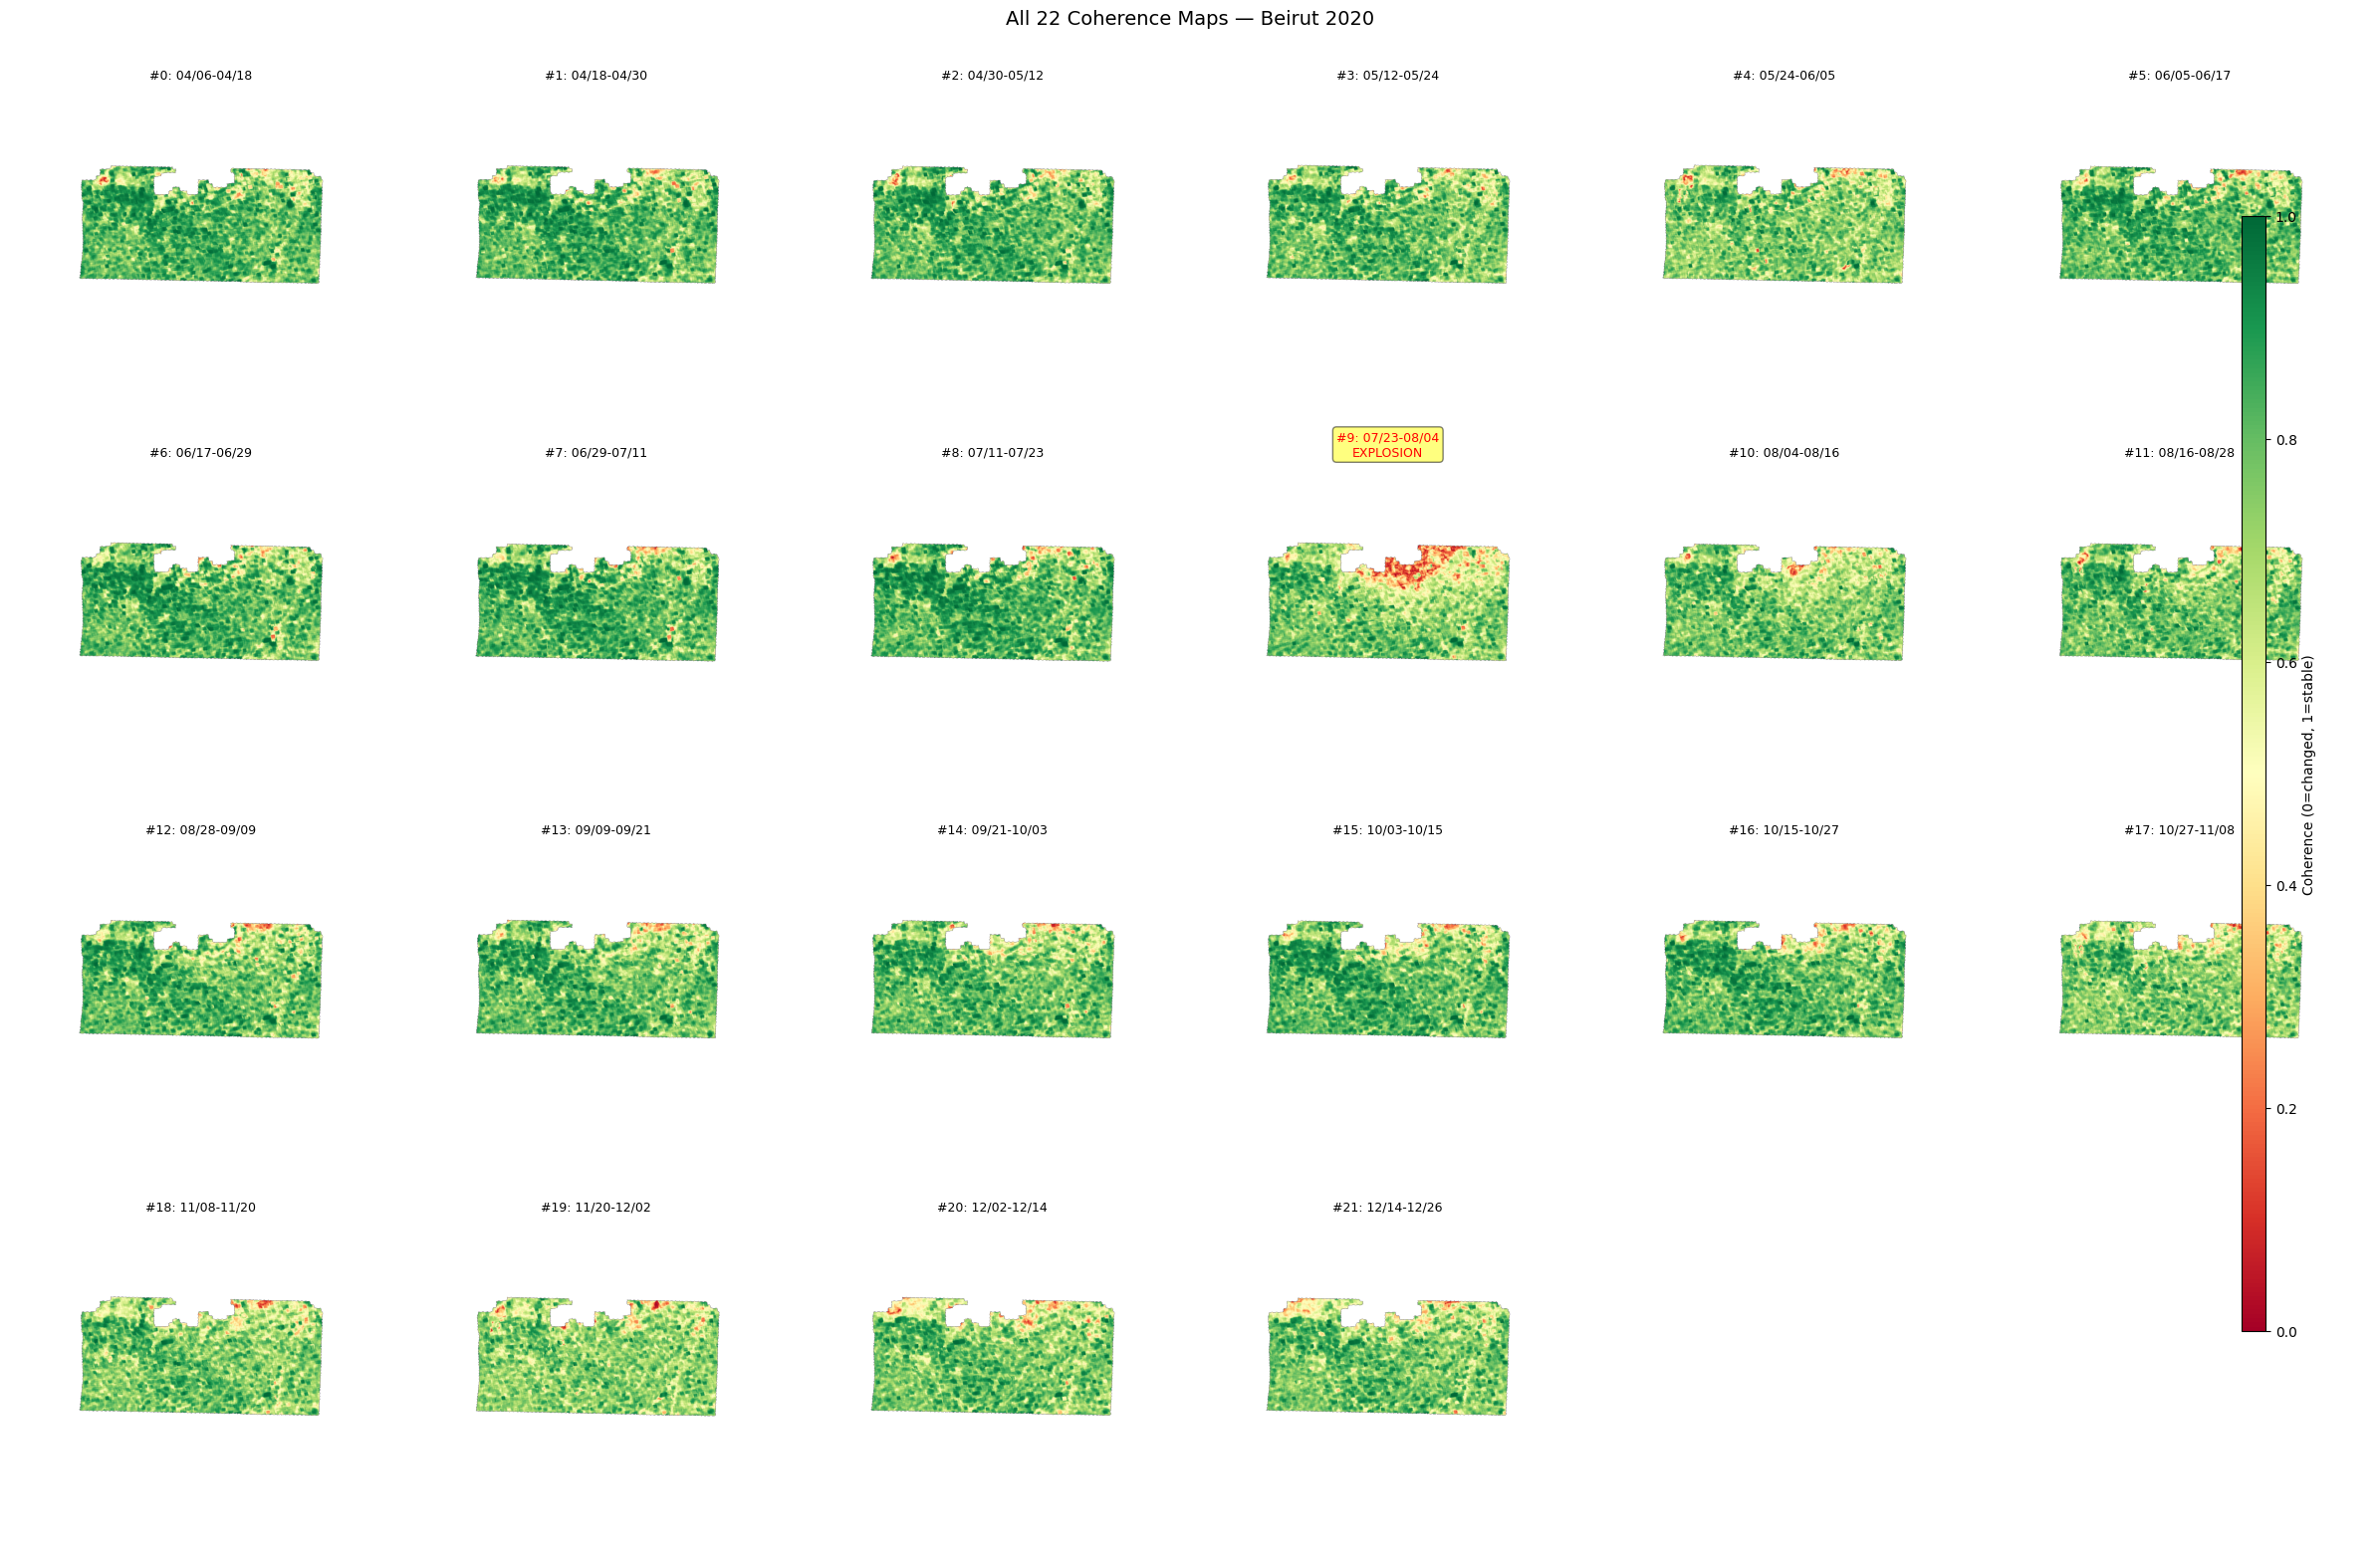

In [5]:
# All 22 maps
fig, axes = plt.subplots(4, 6, figsize=(24, 16))
axes = axes.flatten()

for idx, (ax, coh, date) in enumerate(zip(axes[:22], coherence_stack, dates)):
    im = ax.imshow(coh, cmap='RdYlGn', vmin=0, vmax=1)
    d1, d2 = date.split('_')
    label = f"#{idx}: {d1[4:6]}/{d1[6:8]}-{d2[4:6]}/{d2[6:8]}"
    if idx == EXPLOSION_IDX:
        ax.set_title(label + "\nEXPLOSION", fontsize=9, color='red',
                     bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    else:
        ax.set_title(label, fontsize=9)
    ax.axis('off')

for idx in range(22, len(axes)):
    axes[idx].axis('off')

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.01, 0.7])
fig.colorbar(im, cax=cbar_ax).set_label('Coherence (0=changed, 1=stable)', fontsize=10)
plt.suptitle('All 22 Coherence Maps — Beirut 2020', fontsize=14)
plt.tight_layout()
plt.show()

## Load Building Footprints and Ground Truth

In [6]:
all_buildings = gpd.read_file(
    os.path.join(ground_truth_folder, 'buildings_edit_destroyed.shp')
)

# Clean geometry
all_buildings = all_buildings[
    all_buildings.geometry.notna() & ~all_buildings.geometry.is_empty
].copy()
all_buildings['geometry'] = all_buildings.geometry.buffer(0)
all_buildings = all_buildings.reset_index(drop=True)
all_buildings['building_id'] = range(len(all_buildings))
all_buildings['is_destroyed'] = (all_buildings['Damage'] == 'destroyed').astype(int)
all_buildings = all_buildings.to_crs('EPSG:4326')

print(f"Total buildings: {len(all_buildings)}")
print(f"Destroyed:       {all_buildings['is_destroyed'].sum()}")
print(f"Not destroyed:   {(all_buildings['is_destroyed'] == 0).sum()}")

Total buildings: 7925
Destroyed:       41
Not destroyed:   7884


/tmp/ipykernel_3162/2580914517.py:6: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=11)
/tmp/ipykernel_3162/2580914517.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=11)


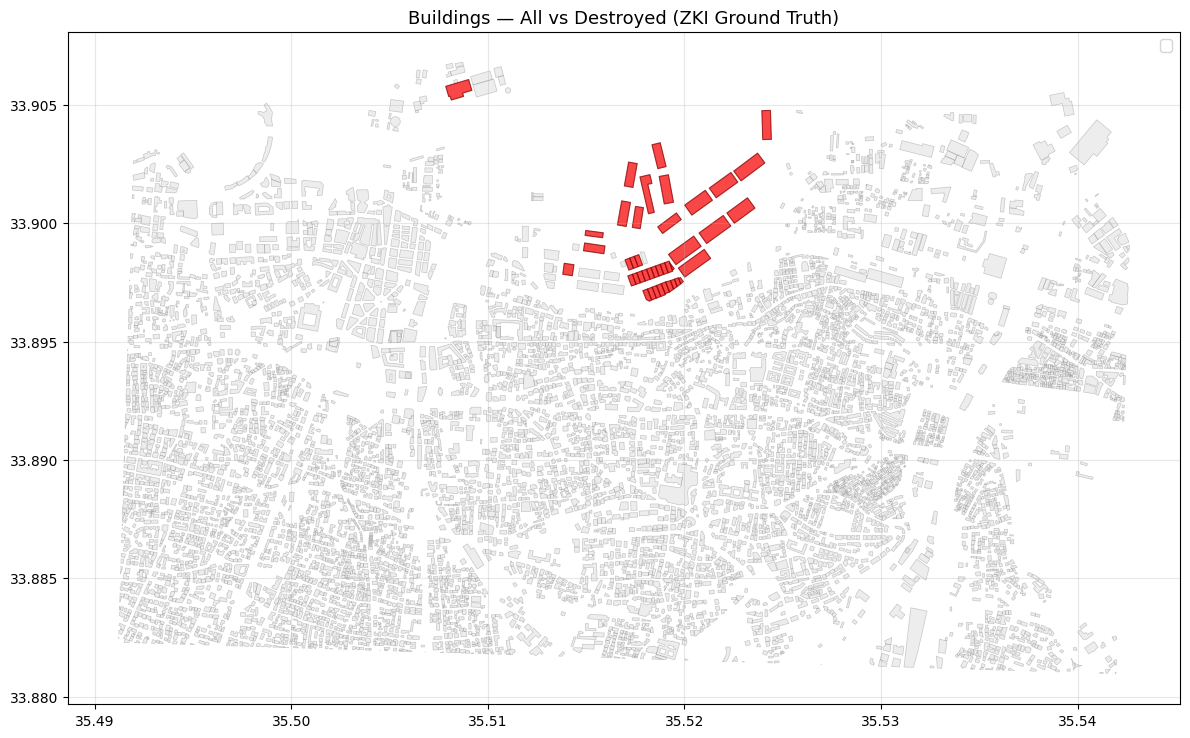

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
all_buildings.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.4, linewidth=0.5, label='All buildings')
all_buildings[all_buildings['is_destroyed'] == 1].plot(
    ax=ax, color='red', edgecolor='darkred', alpha=0.7, linewidth=0.8, label='Destroyed')
ax.set_title('Buildings — All vs Destroyed (ZKI Ground Truth)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3162/1186317323.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


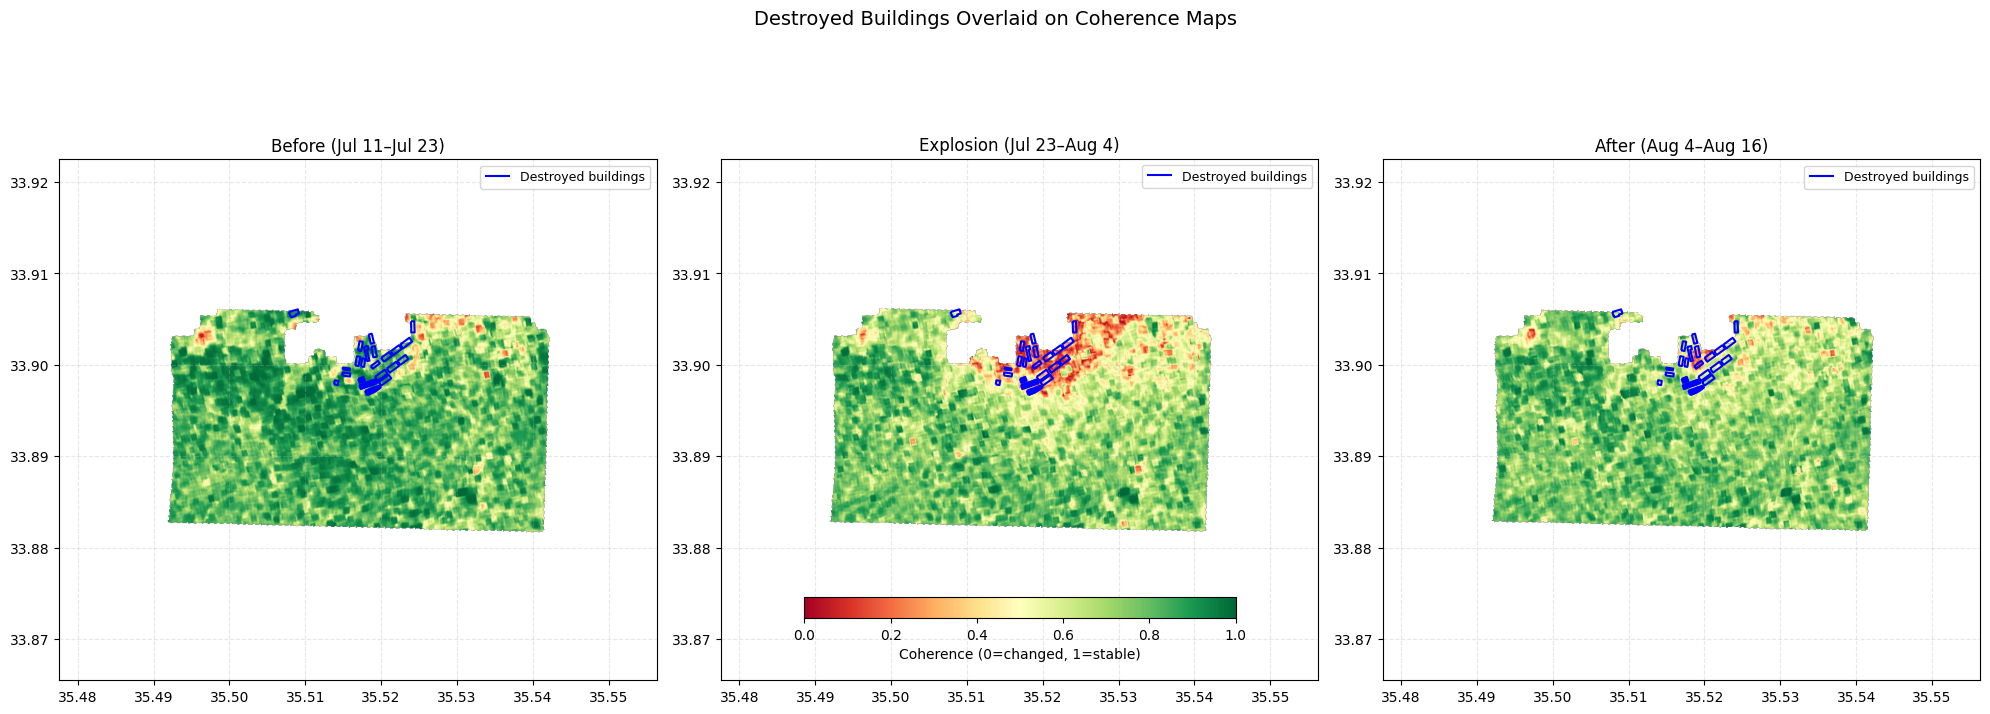

In [8]:
# Overlay destroyed buildings on coherence maps
destroyed = all_buildings[all_buildings['is_destroyed'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
titles = ['Before (Jul 11–Jul 23)', 'Explosion (Jul 23–Aug 4)', 'After (Aug 4–Aug 16)']

for ax, map_idx, title in zip(axes, [8, 9, 10], titles):
    with rasterio.open(coherence_files[map_idx]) as src:
        bounds  = src.bounds
        extent  = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    im = ax.imshow(coherence_stack[map_idx], cmap='RdYlGn', vmin=0, vmax=1,
                   extent=extent, aspect='auto')
    destroyed.boundary.plot(ax=ax, color='blue', linewidth=1.5, label='Destroyed buildings')
    ax.set_title(title, fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.04,
             pad=0.08, label='Coherence (0=changed, 1=stable)')
plt.suptitle('Destroyed Buildings Overlaid on Coherence Maps', fontsize=14)
plt.tight_layout()
plt.show()

## Step 1: Pixel-to-Building Mapping with Coverage Weights

In [9]:
# For each building polygon, find overlapping coherence pixels and compute
# what fraction of each pixel is covered by the building (weight).

pixel_size_x = raster_transform.a
pixel_size_y = abs(raster_transform.e)
pixel_area   = pixel_size_x * pixel_size_y

pixel_building_records = []

for _, building in all_buildings.iterrows():
    geom = building.geometry
    bid  = building['building_id']
    dest = building['is_destroyed']

    minx, miny, maxx, maxy = geom.bounds
    col_min, row_max = ~raster_transform * (minx, miny)
    col_max, row_min = ~raster_transform * (maxx, maxy)

    row_min = max(0, int(np.floor(row_min)))
    row_max = min(raster_shape[0] - 1, int(np.ceil(row_max)))
    col_min = max(0, int(np.floor(col_min)))
    col_max = min(raster_shape[1] - 1, int(np.ceil(col_max)))

    for r in range(row_min, row_max + 1):
        for c in range(col_min, col_max + 1):
            px_left,  px_top    = raster_transform * (c,     r)
            px_right, px_bottom = raster_transform * (c + 1, r + 1)
            pixel_box = box(px_left, px_bottom, px_right, px_top)

            intersection = geom.intersection(pixel_box)
            if not intersection.is_empty and intersection.area > 0:
                weight = intersection.area / pixel_area
                pixel_building_records.append({
                    'building_id': bid, 'row': r, 'col': c,
                    'weight': weight, 'is_destroyed': dest
                })

pixel_building_df = pd.DataFrame(pixel_building_records)
print(f"Total pixel-building pairs: {len(pixel_building_df):,}")
print(f"Unique pixels mapped:       {pixel_building_df[['row','col']].drop_duplicates().shape[0]:,}")

Total pixel-building pairs: 91,358
Unique pixels mapped:       77,325


## Step 2: Build Pixel Time Series and First Differences

In [10]:
# Build (n_pixels × n_times) coherence matrix, compute first differences.

n_times = len(coherence_stack)
building_pixels = pixel_building_df[['row', 'col']].drop_duplicates().reset_index(drop=True)
building_pixels['pixel_id'] = range(len(building_pixels))

pixel_index = {(int(r), int(c)): i
               for i, (r, c) in enumerate(zip(building_pixels['row'], building_pixels['col']))}
n_pixels = len(building_pixels)

coherence_matrix = np.full((n_pixels, n_times), np.nan)
for t, coh_array in enumerate(coherence_stack):
    for _, row_data in building_pixels.iterrows():
        r, c, pid = int(row_data['row']), int(row_data['col']), int(row_data['pixel_id'])
        if 0 <= r < coh_array.shape[0] and 0 <= c < coh_array.shape[1]:
            coherence_matrix[pid, t] = coh_array[r, c]

# Removing pixels with any NaN
valid_mask      = ~np.any(np.isnan(coherence_matrix), axis=1)
coherence_matrix = coherence_matrix[valid_mask]
building_pixels  = building_pixels[valid_mask].reset_index(drop=True)
building_pixels['pixel_id'] = range(len(building_pixels))

# First differences: shape (n_pixels, n_times-1)
diff_matrix = np.diff(coherence_matrix, axis=1)

print(f"Valid pixels:      {len(building_pixels):,}")
print(f"Difference matrix: {diff_matrix.shape}")

Valid pixels:      70,723
Difference matrix: (70723, 21)


## Step 3: Median Regression per Pixel (lambda=10)

In [11]:
# Fitting a quantile (tau=0.5) regression with quadratic trend to each pixel's
# first-difference series, then compute residuals.

LAMBDA = 10
n_diff_periods = diff_matrix.shape[1]
time_points    = np.arange(1, n_diff_periods + 1, dtype=float)


def fit_pixel_regression(pixel_diffs, time_pts):
    X = np.column_stack([np.ones(len(time_pts)), time_pts, time_pts ** 2])
    try:
        result    = QuantReg(pixel_diffs, X).fit(q=0.5, max_iter=1000)
        residuals = pixel_diffs - result.fittedvalues
    except Exception:
        residuals = pixel_diffs - np.median(pixel_diffs)
    return residuals


residual_list = Parallel(n_jobs=-1, verbose=5)(
    delayed(fit_pixel_regression)(diff_matrix[i], time_points)
    for i in range(len(building_pixels))
)

residual_matrix = np.array(residual_list)
print(f"Residual matrix: {residual_matrix.shape}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 652 tasks      | elapsed:    8.3s
[Parallel(n_jobs=-1)]: Done 2092 tasks      | elapsed:   20.7s
[Parallel(n_jobs=-1)]: Done 4108 tasks      | elapsed:   40.4s
[Parallel(n_jobs=-1)]: Done 6700 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 9868 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 13612 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done 17932 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 22828 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done 28300 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done 34348 tasks      | elapsed:  5.1min
[Parallel(n_jobs=-1)]: Done 40972 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 48172 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done 55948 tasks      | elapsed:  8.5min
[Parallel(n_jobs=-1)]: Done 64300 ta

Residual matrix: (70723, 21)


[Parallel(n_jobs=-1)]: Done 70723 out of 70723 | elapsed: 10.9min finished


## Step 4: Qn Robust Scale Estimator and One-sided P-values

In [12]:
# One-sided left-tail p-value: Pr(R <= r) under Normal(0, qn_sd^2).
# Left tail because destruction = coherence drop = negative residual.

def qn_scale(residuals):
    n = len(residuals)
    if n < 2:
        return np.nan
    pairwise_diffs = sorted([
        abs(residuals[i] - residuals[j])
        for i in range(n) for j in range(i + 1, n)
    ])
    h = (n // 2) + 1
    k = min(h * (h - 1) // 2, len(pairwise_diffs) - 1)
    return 2.2219 * pairwise_diffs[k]


qn_scales = np.array([qn_scale(residual_matrix[i]) for i in range(len(building_pixels))])
qn_scales = np.where(
    (qn_scales == 0) | np.isnan(qn_scales),
    np.nanmedian(qn_scales[qn_scales > 0]),
    qn_scales
)

p_value_matrix = np.zeros_like(residual_matrix)
for i in range(len(building_pixels)):
    for t in range(residual_matrix.shape[1]):
        p_value_matrix[i, t] = norm.cdf(residual_matrix[i, t], loc=0, scale=qn_scales[i])

exp_pvals = p_value_matrix[:, EXPLOSION_DIFF_IDX]
print(f"P-values at explosion period:")
print(f"  Median: {np.median(exp_pvals):.4f}")
print(f"  Mean:   {np.mean(exp_pvals):.4f}")
print(f"  p<0.05: {(exp_pvals < 0.05).mean()*100:.1f}%")

P-values at explosion period:
  Median: 0.1114
  Mean:   0.2128
  p<0.05: 38.9%


## Step 5: Weighted Harmonic Mean P-value (Building Level)

In [13]:
# Aggregate pixel p-values to building level using the weighted HMP (Wilson 2019).
# p_B = sum(w) / sum(w/p)  — handles positive dependence between nearby pixels.

def weighted_hmp(p_values, weights):
    p_values = np.clip(p_values, 1e-300, 1.0)
    weights  = np.asarray(weights, dtype=float)
    weights  = weights / weights.sum()
    return np.sum(weights) / np.sum(weights / p_values)


bp_lookup  = building_pixels[['row', 'col', 'pixel_id']].copy()
pbdf_merged = pixel_building_df.merge(bp_lookup, on=['row', 'col'], how='inner')

time_periods = list(range(n_diff_periods))
hmp_records  = []

for bid in all_buildings['building_id'].values:
    pix_rows = pbdf_merged[pbdf_merged['building_id'] == bid]
    if len(pix_rows) == 0:
        continue

    pixel_ids = pix_rows['pixel_id'].values
    weights   = pix_rows['weight'].values
    is_dest   = pix_rows['is_destroyed'].iloc[0]

    valid_mask_b = pixel_ids < len(building_pixels)
    pixel_ids    = pixel_ids[valid_mask_b]
    weights      = weights[valid_mask_b]

    if len(pixel_ids) == 0:
        continue

    for t in time_periods:
        hmp_records.append({
            'building_id':  bid,
            'time_period':  t,
            'hmp':          weighted_hmp(p_value_matrix[pixel_ids, t], weights),
            'is_destroyed': is_dest,
            'is_explosion': int(t == EXPLOSION_DIFF_IDX)
        })

building_hmp_df = pd.DataFrame(hmp_records)
print(f"Building HMP dataframe: {building_hmp_df.shape}")
print(f"Buildings with HMP:     {building_hmp_df['building_id'].nunique()}")

Building HMP dataframe: (153153, 5)
Buildings with HMP:     7293


## Step 6: Performance Evaluation

In [14]:
# Strategy A: destroyed buildings at explosion vs all other time periods
# Strategy B: 99:1 random sampling repeated 100 times

# Strategy A
pos_A = building_hmp_df[(building_hmp_df['is_destroyed'] == 1) &
                         (building_hmp_df['time_period'] == EXPLOSION_DIFF_IDX)]
neg_A = building_hmp_df[(building_hmp_df['is_destroyed'] == 1) &
                         (building_hmp_df['time_period'] != EXPLOSION_DIFF_IDX)]

eval_A   = pd.concat([pos_A.assign(label=1), neg_A.assign(label=0)], ignore_index=True)
y_true_A = eval_A['label'].values
score_A  = -np.log(np.clip(eval_A['hmp'].values, 1e-300, 1.0))

prec_A, rec_A, _  = precision_recall_curve(y_true_A, score_A)
fpr_A,  tpr_A, _  = roc_curve(y_true_A, score_A)
pr_auc_A  = sklearn_auc(rec_A, prec_A)
roc_auc_A = sklearn_auc(fpr_A, tpr_A)

print(f"Strategy A — PR-AUC: {pr_auc_A:.3f}  ROC-AUC: {roc_auc_A:.3f}")

# Strategy B: 99:1 sampling, 100 repetitions
pos_buildings = building_hmp_df[
    (building_hmp_df['is_destroyed'] == 1) &
    (building_hmp_df['time_period'] == EXPLOSION_DIFF_IDX)
].copy()

sample_pool = building_hmp_df[building_hmp_df['time_period'] != EXPLOSION_DIFF_IDX].copy()
n_pos       = len(pos_buildings)
n_neg_need  = n_pos * 99

f1_scores_B, pr_auc_scores_B = [], []

for i in range(100):
    neg_sample = sample_pool.sample(n=min(n_neg_need, len(sample_pool)),
                                    replace=False, random_state=122 + i)
    eval_B  = pd.concat([pos_buildings.assign(label=1), neg_sample.assign(label=0)],
                         ignore_index=True)
    y_true_B = eval_B['label'].values
    score_B  = -np.log(np.clip(eval_B['hmp'].values, 1e-300, 1.0))

    prec_B, rec_B, thresholds_B = precision_recall_curve(y_true_B, score_B)
    f1_vals  = 2 * prec_B * rec_B / np.clip(prec_B + rec_B, 1e-10, None)
    pr_auc_scores_B.append(sklearn_auc(rec_B, prec_B))
    f1_scores_B.append(np.max(f1_vals))

mean_prauc_B = np.mean(pr_auc_scores_B)
std_prauc_B  = np.std(pr_auc_scores_B)
mean_f1_B    = np.mean(f1_scores_B)
std_f1_B     = np.std(f1_scores_B)

best_thresh_idx = np.argmax(f1_vals)
optimal_hmp_threshold = (
    np.exp(-thresholds_B[best_thresh_idx])
    if best_thresh_idx < len(thresholds_B) else 0.05
)

print(f"Strategy B — PR-AUC: {mean_prauc_B:.3f} ± {std_prauc_B:.3f}")
print(f"             F1:     {mean_f1_B:.3f} ± {std_f1_B:.3f}")
print(f"Optimal HMP threshold: {optimal_hmp_threshold:.6f}")

Strategy A — PR-AUC: 0.834  ROC-AUC: 0.994
Strategy B — PR-AUC: 0.820 ± 0.053
             F1:     0.788 ± 0.030
Optimal HMP threshold: 0.000038


## Step 7: Visualisation

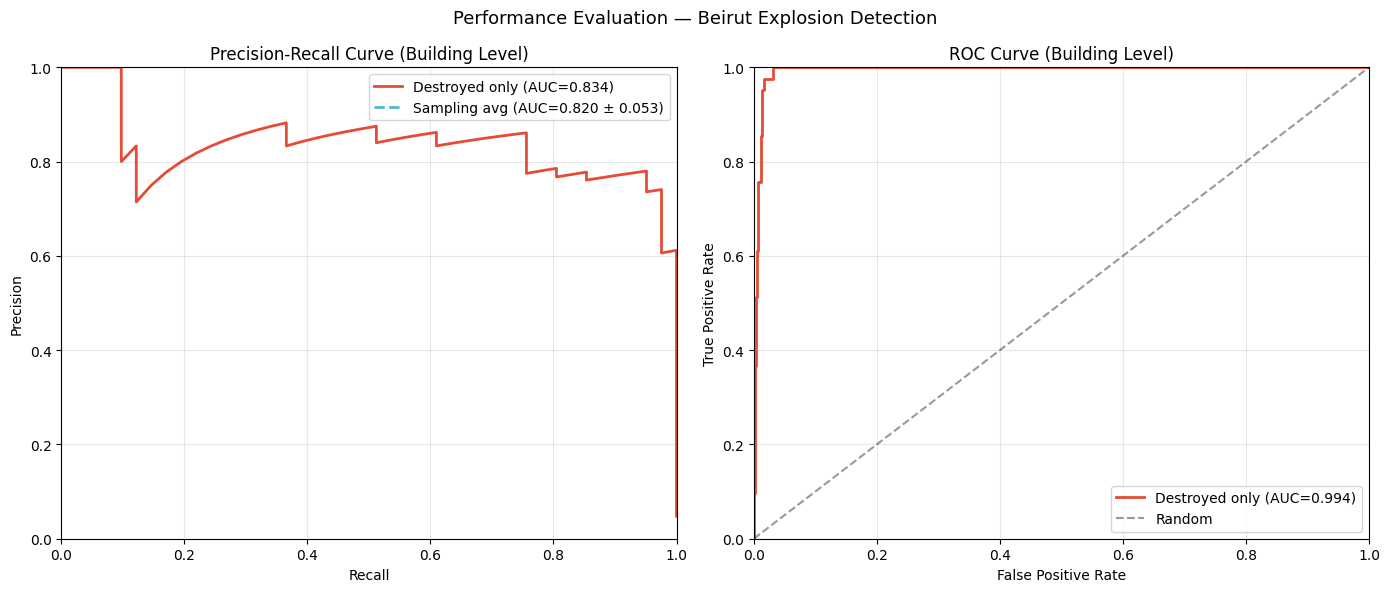

In [15]:
# PR and ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(rec_A, prec_A, color='#E64B35', lw=2,
             label=f'Destroyed only (AUC={pr_auc_A:.3f})')
axes[0].plot([], [], color='#4DBBD5', lw=2, ls='--',
             label=f'Sampling avg (AUC={mean_prauc_B:.3f} ± {std_prauc_B:.3f})')
axes[0].set(xlabel='Recall', ylabel='Precision', xlim=(0,1), ylim=(0,1),
            title='Precision-Recall Curve (Building Level)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(fpr_A, tpr_A, color='#E64B35', lw=2,
             label=f'Destroyed only (AUC={roc_auc_A:.3f})')
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, label='Random')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            xlim=(0,1), ylim=(0,1), title='ROC Curve (Building Level)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Performance Evaluation — Beirut Explosion Detection', fontsize=13)
plt.tight_layout()
plt.show()

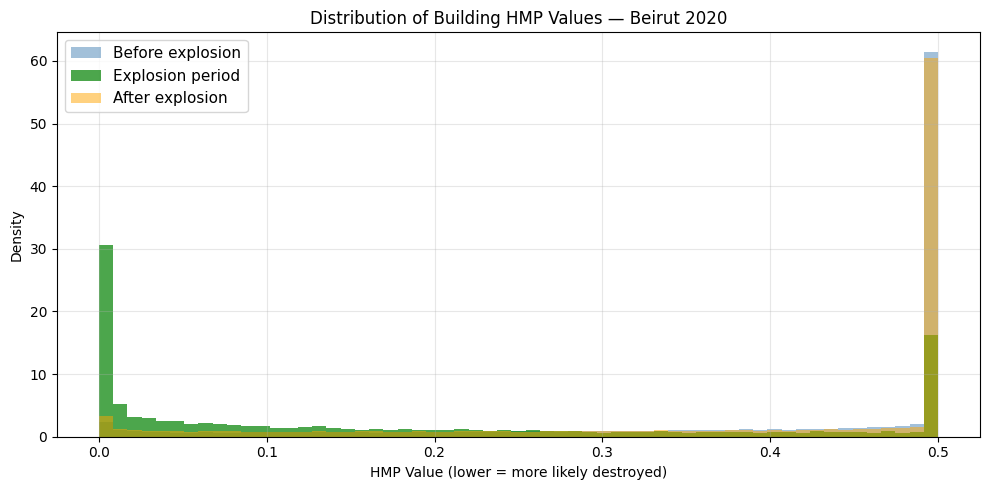

In [16]:
# HMP distribution before / during / after explosion
before_pvals    = building_hmp_df[building_hmp_df['time_period'] < EXPLOSION_DIFF_IDX]['hmp']
explosion_pvals = building_hmp_df[building_hmp_df['time_period'] == EXPLOSION_DIFF_IDX]['hmp']
after_pvals     = building_hmp_df[building_hmp_df['time_period'] > EXPLOSION_DIFF_IDX]['hmp']

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 0.5, 60)
ax.hist(before_pvals.clip(0,0.5),    bins=bins, density=True, alpha=0.5,
        color='steelblue', label='Before explosion')
ax.hist(explosion_pvals.clip(0,0.5), bins=bins, density=True, alpha=0.7,
        color='green',    label='Explosion period')
ax.hist(after_pvals.clip(0,0.5),     bins=bins, density=True, alpha=0.5,
        color='orange',   label='After explosion')
ax.set(xlabel='HMP Value (lower = more likely destroyed)', ylabel='Density',
       title='Distribution of Building HMP Values — Beirut 2020')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3162/3254597101.py:39: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[2].legend(fontsize=9, loc='upper right')
/tmp/ipykernel_3162/3254597101.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=9, loc='upper right')


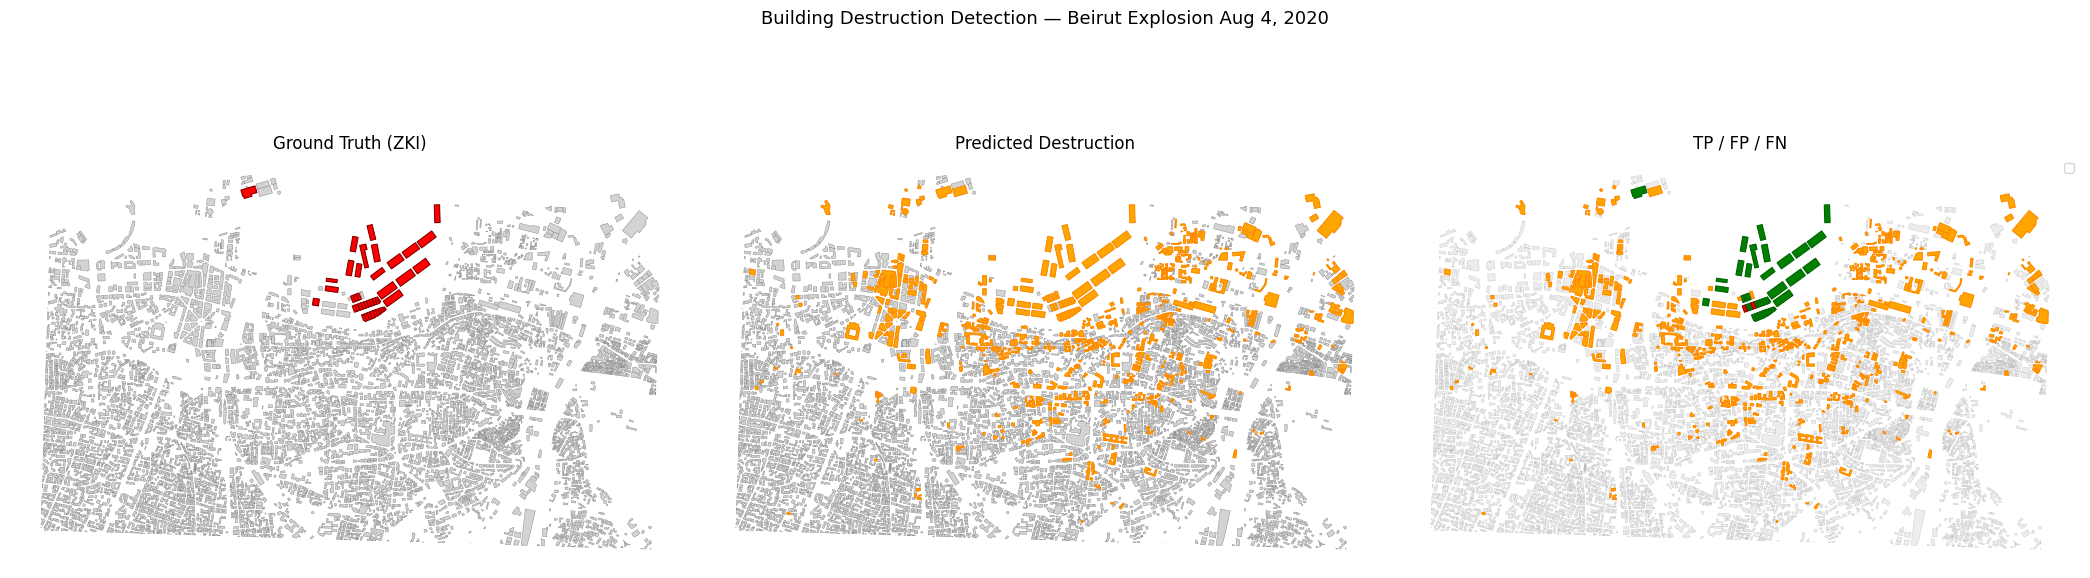

In [17]:
# Classification map — ground truth vs predictions vs TP/FP/FN
explosion_hmp = building_hmp_df[
    building_hmp_df['time_period'] == EXPLOSION_DIFF_IDX
][['building_id','hmp','is_destroyed']].copy()
explosion_hmp['predicted_destroyed'] = (explosion_hmp['hmp'] < optimal_hmp_threshold).astype(int)

buildings_with_pred = all_buildings.merge(
    explosion_hmp[['building_id','hmp','predicted_destroyed']],
    on='building_id', how='left'
)
buildings_with_pred['predicted_destroyed'] = \
    buildings_with_pred['predicted_destroyed'].fillna(0).astype(int)

confirmed = buildings_with_pred[buildings_with_pred['is_destroyed'] == 1]
predicted = buildings_with_pred[buildings_with_pred['predicted_destroyed'] == 1]
tp_buildings = buildings_with_pred[(buildings_with_pred['is_destroyed']==1) & (buildings_with_pred['predicted_destroyed']==1)]
fp_buildings = buildings_with_pred[(buildings_with_pred['is_destroyed']==0) & (buildings_with_pred['predicted_destroyed']==1)]
fn_buildings = buildings_with_pred[(buildings_with_pred['is_destroyed']==1) & (buildings_with_pred['predicted_destroyed']==0)]

fig, axes = plt.subplots(1, 3, figsize=(21, 7))

# Ground truth
buildings_with_pred.plot(ax=axes[0], color='lightgray', edgecolor='gray', linewidth=0.3)
confirmed.plot(ax=axes[0], color='red', edgecolor='darkred', linewidth=0.8)
axes[0].set_title('Ground Truth (ZKI)', fontsize=12)
axes[0].axis('off')

# Predictions
buildings_with_pred.plot(ax=axes[1], color='lightgray', edgecolor='gray', linewidth=0.3)
predicted.plot(ax=axes[1], color='orange', edgecolor='darkorange', linewidth=0.8)
axes[1].set_title('Predicted Destruction', fontsize=12)
axes[1].axis('off')

# TP / FP / FN
buildings_with_pred.plot(ax=axes[2], color='lightgray', edgecolor='gray', linewidth=0.3, alpha=0.4)
if len(tp_buildings): tp_buildings.plot(ax=axes[2], color='green',  edgecolor='darkgreen',  lw=0.8, label=f'TP ({len(tp_buildings)})')
if len(fp_buildings): fp_buildings.plot(ax=axes[2], color='orange', edgecolor='darkorange', lw=0.8, label=f'FP ({len(fp_buildings)})')
if len(fn_buildings): fn_buildings.plot(ax=axes[2], color='red',    edgecolor='darkred',    lw=0.8, label=f'FN ({len(fn_buildings)})')
axes[2].legend(fontsize=9, loc='upper right')
axes[2].set_title('TP / FP / FN', fontsize=12)
axes[2].axis('off')

plt.suptitle('Building Destruction Detection — Beirut Explosion Aug 4, 2020', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
tp = len(tp_buildings)
fp = len(fp_buildings)
fn = len(fn_buildings)
prec_final = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_final  = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_final   = 2 * prec_final * rec_final / (prec_final + rec_final) if (prec_final + rec_final) > 0 else 0

print("Performance Summary")
print(f"  True Positives:  {tp}")
print(f"  False Positives: {fp}")
print(f"  False Negatives: {fn}")
print(f"  Precision:       {prec_final:.3f}")
print(f"  Recall:          {rec_final:.3f}")
print(f"  F1 Score:        {f1_final:.3f}")
print(f"  PR-AUC (A):      {pr_auc_A:.3f}")
print(f"  PR-AUC (B):      {mean_prauc_B:.3f} +/- {std_prauc_B:.3f}")
print(f"  ROC-AUC (A):     {roc_auc_A:.3f}")

Performance Summary
  True Positives:  39
  False Positives: 757
  False Negatives: 2
  Precision:       0.049
  Recall:          0.951
  F1 Score:        0.093
  PR-AUC (A):      0.834
  PR-AUC (B):      0.820 +/- 0.053
  ROC-AUC (A):     0.994


## Step 8: Damage Grading and Reconstruction Cost Estimation

In [19]:
# Map HMP -> EMS-98 damage grade, estimate reconstruction cost per building,
# and run a Monte Carlo simulation to get a P10/P50/P90 cost range.

CITY = "Beirut"   # change to "Mariupol" or "Gaza" as needed

CITY_CONFIG = {
    "Beirut": {
        "crs_epsg": 32636, "default_floors": 4,
        "unit_costs": {"D5": 1100, "D4": 750, "D3": 400, "D2": 150, "D1": 50, "D0": 0},
    },
    "Mariupol": {
        "crs_epsg": 32637, "default_floors": 7,
        "unit_costs": {"D5": 850, "D4": 580, "D3": 310, "D2": 110, "D1": 35, "D0": 0},
    },
    "Gaza": {
        "crs_epsg": 32636, "default_floors": 3,
        "unit_costs": {"D5": 700, "D4": 480, "D3": 260, "D2": 90, "D1": 30, "D0": 0},
    },
}
cfg = CITY_CONFIG[CITY]

# EMS-98 thresholds — lower HMP = more severe damage
GRADE_THRESHOLDS = {
    "D5": 0.005,
    "D4": 0.01,
    "D3": 0.03,
    "D2": optimal_hmp_threshold,
    "D1": 0.10,
}


def assign_damage_grade(hmp_val):
    for grade, thresh in GRADE_THRESHOLDS.items():
        if hmp_val <= thresh:
            return grade
    return "D0"


explosion_hmp_cost = building_hmp_df[
    building_hmp_df["time_period"] == EXPLOSION_DIFF_IDX
][["building_id", "hmp", "is_destroyed"]].copy()
explosion_hmp_cost["damage_grade"] = explosion_hmp_cost["hmp"].apply(assign_damage_grade)

buildings_metric = all_buildings.to_crs(epsg=cfg["crs_epsg"]).copy()
buildings_metric["footprint_m2"] = buildings_metric.geometry.area
if "building:l" in buildings_metric.columns:
    buildings_metric["floors"] = pd.to_numeric(
        buildings_metric["building:l"], errors="coerce"
    ).fillna(cfg["default_floors"])
else:
    buildings_metric["floors"] = cfg["default_floors"]
buildings_metric["floor_area_m2"] = buildings_metric["footprint_m2"] * buildings_metric["floors"]

buildings_metric = buildings_metric.merge(
    explosion_hmp_cost[["building_id", "hmp", "damage_grade", "is_destroyed"]],
    on="building_id", how="left"
)
buildings_metric["damage_grade"] = buildings_metric["damage_grade"].fillna("D0")
buildings_metric["unit_cost_usd_m2"] = buildings_metric["damage_grade"].map(cfg["unit_costs"])
buildings_metric["recon_cost_usd"]   = buildings_metric["floor_area_m2"] * buildings_metric["unit_cost_usd_m2"]

# Monte Carlo: sample 1000 HMP values per building, get P10/P50/P90 cost
N_SIM = 1000
rng   = np.random.default_rng(seed=42)


def sample_cost_distribution(row):
    hmp_samples = rng.lognormal(
        mean=np.log(max(row["hmp"], 1e-10)), sigma=0.25, size=N_SIM
    )
    costs = [row["floor_area_m2"] * cfg["unit_costs"][assign_damage_grade(h)] for h in hmp_samples]
    return pd.Series(np.percentile(costs, [10, 50, 90]), index=["cost_p10", "cost_p50", "cost_p90"])


cost_bounds      = buildings_metric.apply(sample_cost_distribution, axis=1)
buildings_metric = pd.concat([buildings_metric, cost_bounds], axis=1)

n_damaged  = (buildings_metric["damage_grade"] != "D0").sum()
total_p50  = buildings_metric["cost_p50"].sum() / 1e6

print(f"Damage grade distribution ({CITY}):")
print(buildings_metric["damage_grade"].value_counts().sort_index().to_string())
print(f"\nBuildings with detectable damage: {n_damaged}")
print(f"P10: ${buildings_metric['cost_p10'].sum()/1e6:,.1f}M")
print(f"P50: ${total_p50:,.1f}M")
print(f"P90: ${buildings_metric['cost_p90'].sum()/1e6:,.1f}M")

Damage grade distribution (Beirut):
damage_grade
D0    4336
D1    1069
D3     561
D4     280
D5    1679

Buildings with detectable damage: 3589
P10: $4,815.2M
P50: $5,022.6M
P90: $5,295.3M


## Step 9: Insurance Loss Estimation

In [20]:
# Apply insurance policy mechanics to a synthetic portfolio,
# then run Monte Carlo to get the aggregate loss distribution.

PORTFOLIO_CONFIG = {
    "Beirut":   {"penetration": 0.60, "replacement_rate": 1500,
                 "si_ratio_range": (0.70, 1.00), "deductible_range": (0.02, 0.05), "coverage_range": (0.80, 1.00)},
    "Mariupol": {"penetration": 0.35, "replacement_rate": 1100,
                 "si_ratio_range": (0.50, 0.90), "deductible_range": (0.01, 0.03), "coverage_range": (0.70, 1.00)},
    "Gaza":     {"penetration": 0.10, "replacement_rate": 900,
                 "si_ratio_range": (0.60, 0.90), "deductible_range": (0.02, 0.05), "coverage_range": (0.80, 1.00)},
}
pc = PORTFOLIO_CONFIG[CITY]

np.random.seed(42)
insured_mask  = np.random.rand(len(buildings_metric)) < pc["penetration"]
insured_bldgs = buildings_metric[insured_mask].copy().reset_index(drop=True)

insured_bldgs["replacement_value_usd"] = insured_bldgs["floor_area_m2"] * pc["replacement_rate"]
insured_bldgs["insured_value_usd"]     = (
    insured_bldgs["replacement_value_usd"]
    * np.random.uniform(*pc["si_ratio_range"], len(insured_bldgs))
)
insured_bldgs["deductible_usd"] = (
    insured_bldgs["insured_value_usd"]
    * np.random.uniform(*pc["deductible_range"], len(insured_bldgs))
)
insured_bldgs["coverage_pct"] = np.random.uniform(*pc["coverage_range"], len(insured_bldgs))

insured_bldgs["ground_up_loss_usd"]  = insured_bldgs["recon_cost_usd"].fillna(0)
insured_bldgs["above_deductible_usd"] = np.maximum(
    insured_bldgs["ground_up_loss_usd"] - insured_bldgs["deductible_usd"], 0)
insured_bldgs["insured_loss_usd"]    = np.minimum(
    insured_bldgs["above_deductible_usd"] * insured_bldgs["coverage_pct"],
    insured_bldgs["insured_value_usd"])
insured_bldgs["claim_likely"]        = (
    insured_bldgs["insured_loss_usd"] > 0.05 * insured_bldgs["insured_value_usd"]).astype(int)


def run_portfolio_simulation(df, n_sim=1000):
    total_losses = []
    for _ in range(n_sim):
        q = np.random.uniform(0, 1, len(df))
        sim_ground_up = df["cost_p10"] + q * (df["cost_p90"] - df["cost_p10"])
        sim_above_ded = np.maximum(sim_ground_up - df["deductible_usd"], 0)
        sim_insured   = np.minimum(sim_above_ded * df["coverage_pct"], df["insured_value_usd"])
        total_losses.append(sim_insured.sum())
    return np.array(total_losses)


loss_dist  = run_portfolio_simulation(insured_bldgs)
mean_loss  = loss_dist.mean()
var_95     = np.percentile(loss_dist, 95)
var_99     = np.percentile(loss_dist, 99)
tvar_95    = loss_dist[loss_dist >= var_95].mean()

print(f"Insurance Loss Report — {CITY}")
print(f"  Insured buildings:        {len(insured_bldgs):,}")
print(f"  Claims likely triggered:  {insured_bldgs['claim_likely'].sum():,}")
print(f"  Expected loss (mean):     ${mean_loss/1e6:,.2f}M")
print(f"  VaR @ 95%:                ${var_95/1e6:,.2f}M")
print(f"  VaR @ 99%:                ${var_99/1e6:,.2f}M")
print(f"  TVaR @ 95%:               ${tvar_95/1e6:,.2f}M")

Insurance Loss Report — Beirut
  Insured buildings:        4,815
  Claims likely triggered:  1,517
  Expected loss (mean):     $2,625.99M
  VaR @ 95%:                $2,633.29M
  VaR @ 99%:                $2,635.02M
  TVaR @ 95%:               $2,634.26M


## Step 9D: Visualisation and CSV Export

/tmp/ipykernel_3162/2497744533.py:42: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax_map.legend(title='Insured loss', fontsize=9, title_fontsize=9, loc='upper right')
/tmp/ipykernel_3162/2497744533.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_map.legend(title='Insured loss', fontsize=9, title_fontsize=9, loc='upper right')
/tmp/ipykernel_3162/2497744533.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


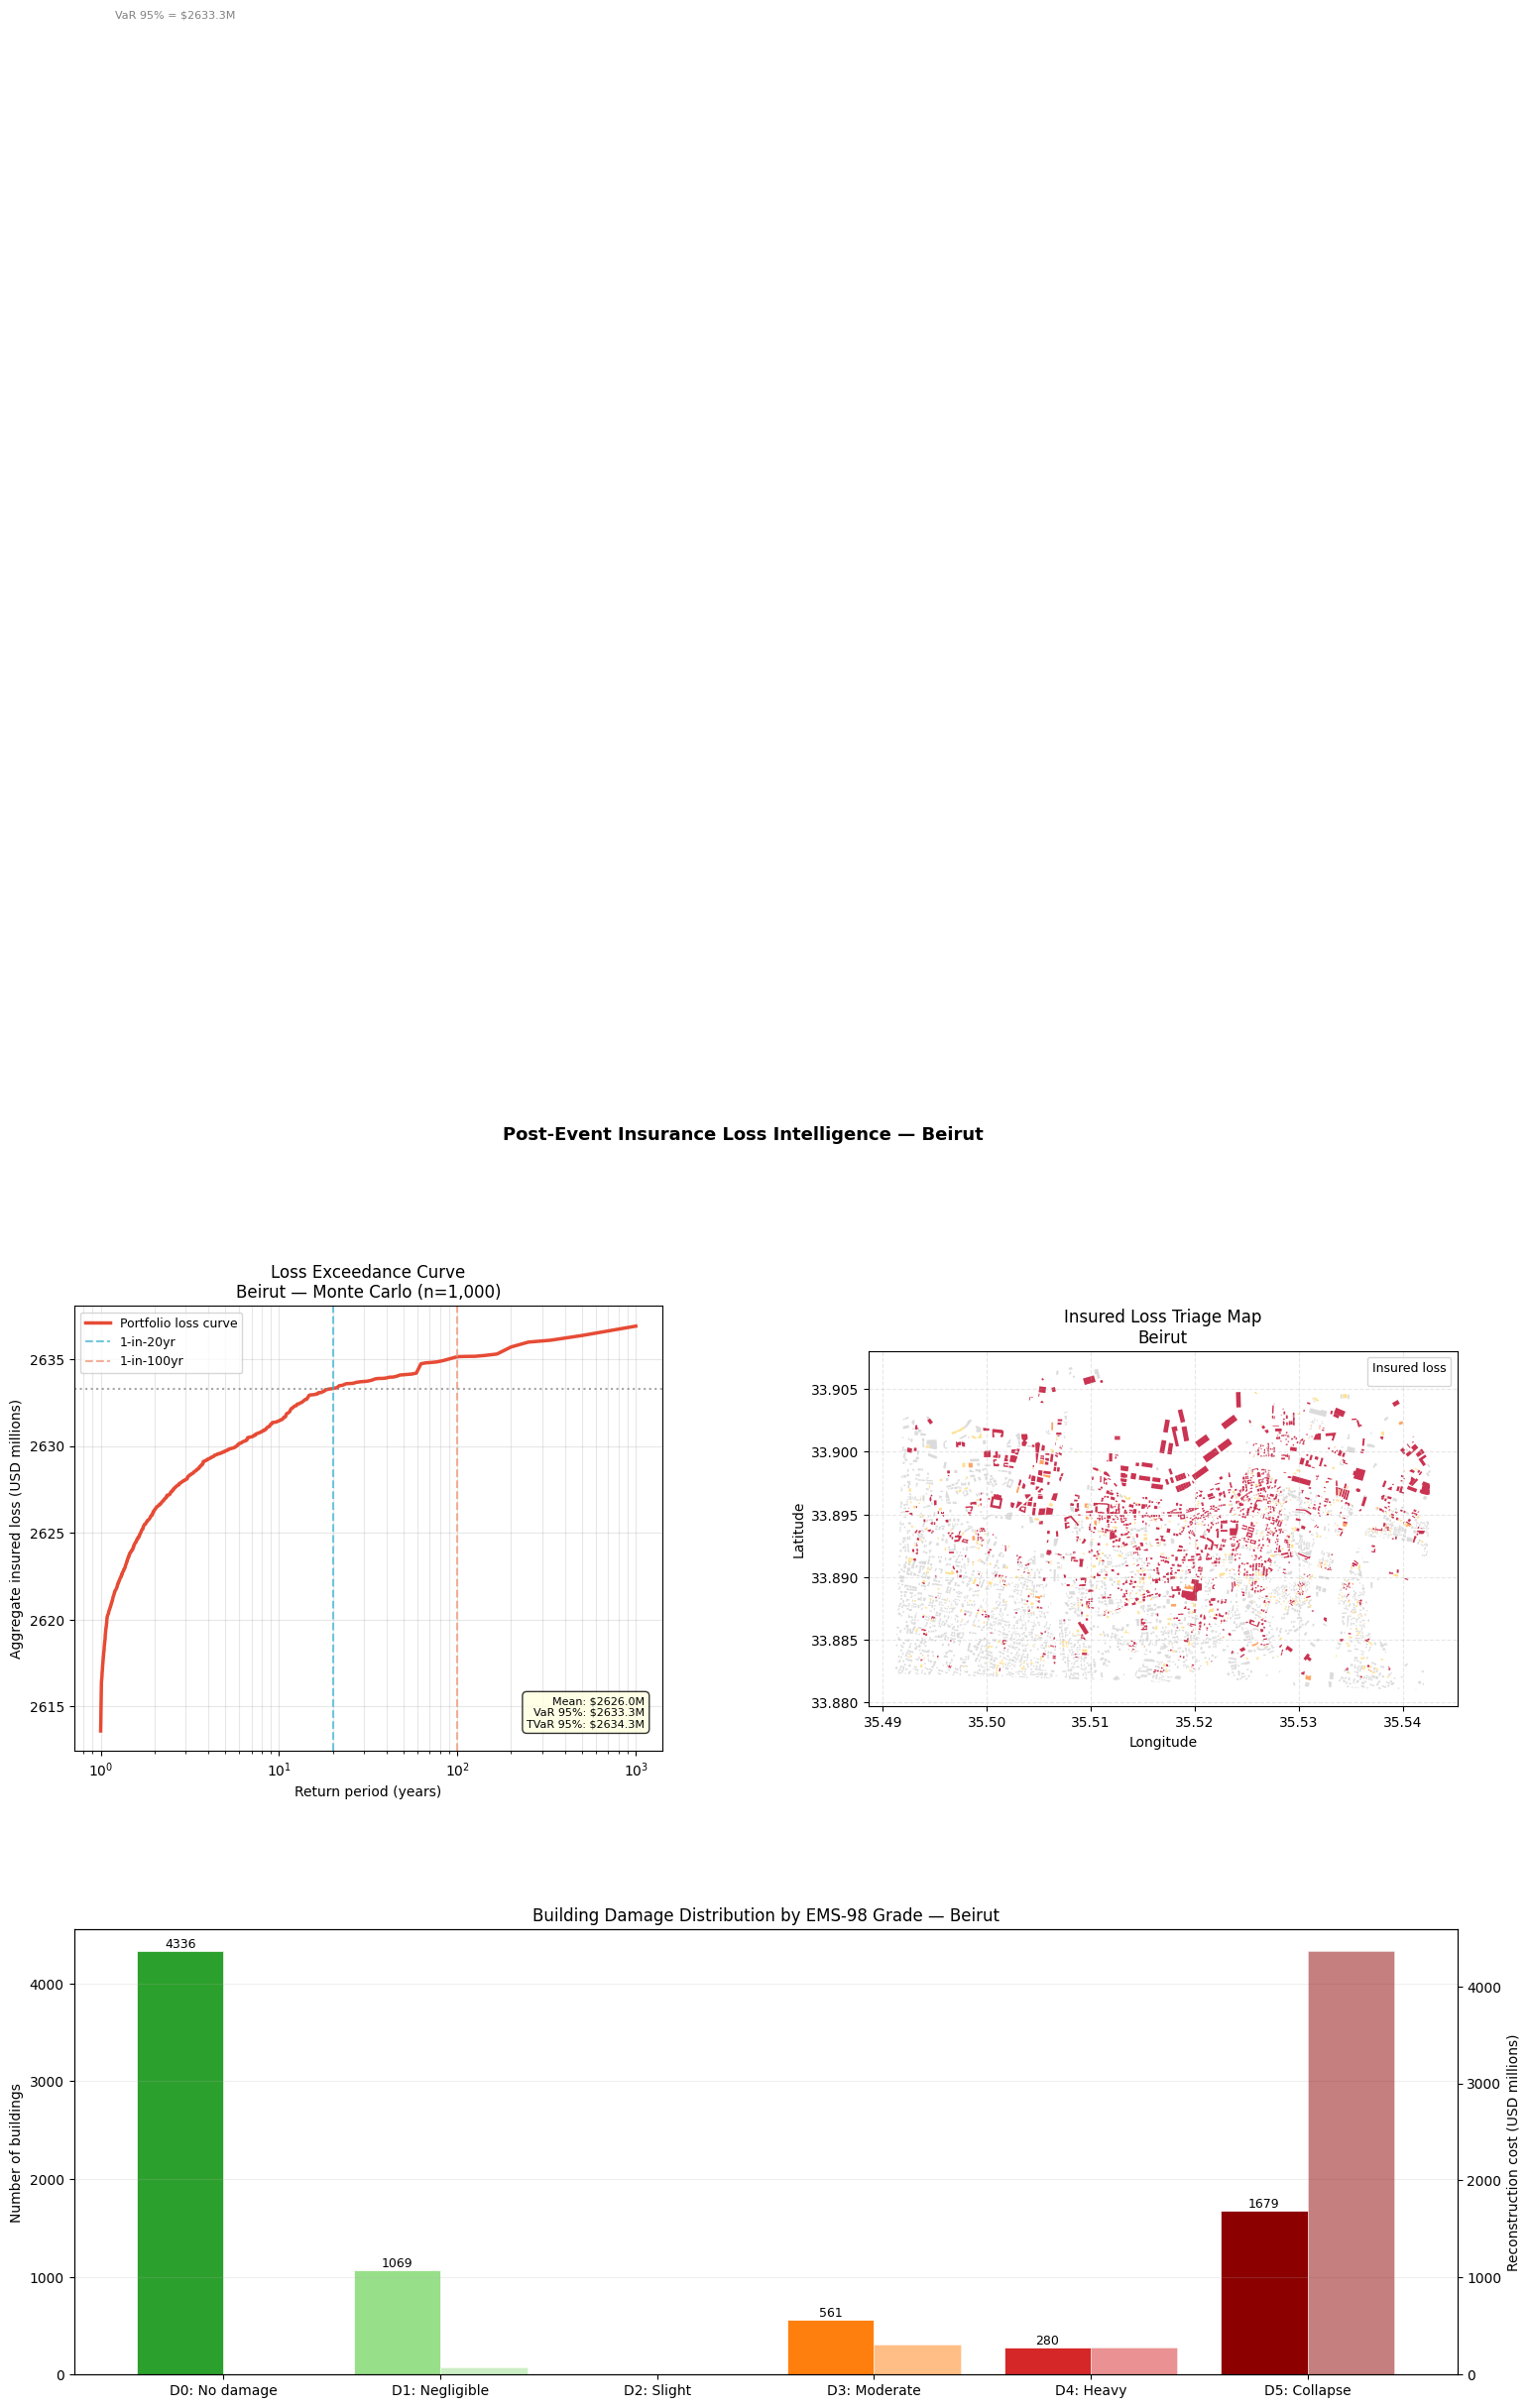

Report saved to: /content/drive/MyDrive/Beirut_insurance_loss_report.csv


In [21]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
ax_curve  = fig.add_subplot(gs[0, 0])
ax_map    = fig.add_subplot(gs[0, 1])
ax_grades = fig.add_subplot(gs[1, :])

# Loss exceedance curve
sorted_losses   = np.sort(loss_dist)[::-1]
exceedance_prob = np.arange(1, len(sorted_losses) + 1) / len(sorted_losses)
return_period   = 1.0 / exceedance_prob

ax_curve.plot(return_period, sorted_losses / 1e6, color='#E64B35', lw=2.5, label='Portfolio loss curve')
ax_curve.axvline(20,  color='#4DBBD5', ls='--', lw=1.5, alpha=0.8, label='1-in-20yr')
ax_curve.axvline(100, color='#F39B7F', ls='--', lw=1.5, alpha=0.8, label='1-in-100yr')
ax_curve.axhline(var_95 / 1e6, color='gray', ls=':', alpha=0.7)
ax_curve.text(1.2, var_95 / 1e6 * 1.03, f"VaR 95% = ${var_95/1e6:.1f}M", fontsize=8, color='gray')
ax_curve.set_xscale('log')
ax_curve.set(xlabel='Return period (years)', ylabel='Aggregate insured loss (USD millions)',
             title=f'Loss Exceedance Curve\n{CITY} — Monte Carlo (n=1,000)')
ax_curve.legend(fontsize=9, loc='upper left')
ax_curve.grid(True, alpha=0.3, which='both')
stats_text = f"Mean: ${mean_loss/1e6:.1f}M\nVaR 95%: ${var_95/1e6:.1f}M\nTVaR 95%: ${tvar_95/1e6:.1f}M"
ax_curve.text(0.97, 0.05, stats_text, transform=ax_curve.transAxes, fontsize=8,
              va='bottom', ha='right', bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.8))

# Building-level triage map
tiers = [
    (insured_bldgs[insured_bldgs['insured_loss_usd'] == 0],           'lightgray', 'No loss'),
    (insured_bldgs[(insured_bldgs['insured_loss_usd'] > 0) &
                    (insured_bldgs['insured_loss_usd'] < 50_000)],    '#FED976',   '< $50k'),
    (insured_bldgs[(insured_bldgs['insured_loss_usd'] >= 50_000) &
                    (insured_bldgs['insured_loss_usd'] < 200_000)],   '#FD8D3C',   '$50k-$200k'),
    (insured_bldgs[insured_bldgs['insured_loss_usd'] >= 200_000],     '#BD0026',   '> $200k'),
]
for gdf_tier, color, label in tiers:
    if len(gdf_tier) > 0:
        gdf_tier.to_crs(epsg=4326).plot(ax=ax_map, color=color, alpha=0.8, lw=0.4, label=label)
ax_map.set(title=f'Insured Loss Triage Map\n{CITY}', xlabel='Longitude', ylabel='Latitude')
ax_map.legend(title='Insured loss', fontsize=9, title_fontsize=9, loc='upper right')
ax_map.grid(True, alpha=0.3, linestyle='--')

# Damage grade distribution
grade_order  = ['D0', 'D1', 'D2', 'D3', 'D4', 'D5']
grade_colors = {'D0':'#2ca02c','D1':'#98df8a','D2':'#ffbb78','D3':'#ff7f0e','D4':'#d62728','D5':'#8c0000'}
grade_labels = {'D0':'D0: No damage','D1':'D1: Negligible','D2':'D2: Slight',
                'D3':'D3: Moderate','D4':'D4: Heavy','D5':'D5: Collapse'}

grade_counts = buildings_metric['damage_grade'].value_counts().reindex(grade_order, fill_value=0)
grade_costs  = buildings_metric.groupby('damage_grade')['recon_cost_usd'].sum().reindex(grade_order, fill_value=0) / 1e6

x     = np.arange(len(grade_order))
width = 0.4
bars  = ax_grades.bar(x - width/2, grade_counts.values, width=width,
                       color=[grade_colors[g] for g in grade_order],
                       edgecolor='white', lw=0.5, label='Building count')
ax2   = ax_grades.twinx()
ax2.bar(x + width/2, grade_costs.values, width=width,
        color=[grade_colors[g] for g in grade_order],
        edgecolor='white', lw=0.5, alpha=0.5, label='Recon cost $M')

ax_grades.set_xticks(x)
ax_grades.set_xticklabels([grade_labels[g] for g in grade_order], fontsize=10)
ax_grades.set(ylabel='Number of buildings', title=f'Building Damage Distribution by EMS-98 Grade — {CITY}')
ax2.set_ylabel('Reconstruction cost (USD millions)')
ax_grades.grid(True, alpha=0.2, axis='y')

for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax_grades.text(bar.get_x() + bar.get_width()/2, h + 0.5, str(int(h)),
                       ha='center', va='bottom', fontsize=9)

fig.suptitle(f'Post-Event Insurance Loss Intelligence — {CITY}', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Export CSV
report_df = insured_bldgs[[
    'building_id', 'damage_grade', 'floor_area_m2',
    'recon_cost_usd', 'cost_p10', 'cost_p50', 'cost_p90',
    'insured_value_usd', 'deductible_usd', 'coverage_pct',
    'ground_up_loss_usd', 'insured_loss_usd', 'claim_likely', 'hmp'
]].sort_values('insured_loss_usd', ascending=False).reset_index(drop=True)

output_path = f'/content/drive/MyDrive/{CITY}_insurance_loss_report.csv'
report_df.to_csv(output_path, index=False)
print(f"Report saved to: {output_path}")